In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import skew, kurtosis
from matplotlib.patches import Patch

In [2]:
#loading dataset
df = pd.read_excel("Data.xlsm")

In [3]:
#checking dataset
print("Raw dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Raw dataset shape: (315632, 18)

First 5 rows:


,SETTLEMENTDATE,SA1_Price,SA1_Demand,AGLHAL_SA1_Natural Gas,ANGASTON_SA1_Diesel,CLEMGPWF_SA1_Wind,QUARANTN_SA1_Natural Gas,LONSDALE_SA1_Diesel,STANVAC_SA1_Diesel,HORNSDPR_SA1_Battery Storage,BNGSF1_SA1_Solar,BARKIPS_SA1_Natural Gas,ADP_SA1_Battery Storage,MAPS2_SA1_Solar,BOLIVAR_SA1_Battery Storage,CATHROCK_SA1_Wind,STARFHILL_SA1_Wind,HVWW_SA1_Solar
0,2022-07-01 00:04:59,379.96000,1654.10,0.0,36.0,44.60929,0.0,2.02342,0.0,0,0.0,111.05,0,0.0,0,2.961,13.59604,0.0
1,2022-07-01 00:09:59,365.35543,1621.37,0.0,0.0,48.52170,0.0,0.00000,0.0,0,0.0,79.59,0,0.0,0,5.017,16.69513,0.0
2,2022-07-01 00:14:59,374.62919,1642.13,0.0,0.0,48.17684,0.0,0.00000,0.0,0,0.0,52.03,0,0.0,0,6.045,16.39522,0.0
3,2022-07-01 00:19:59,379.53476,1619.22,0.0,0.0,48.06833,0.0,0.00000,0.0,0,0.0,22.77,0,0.0,0,4.573,16.29525,0.0
4,2022-07-01 00:24:59,369.74124,1633.80,0.0,0.0,43.18745,0.0,0.00000,0.0,0,0.0,9.00,0,0.0,0,3.379,14.09589,0.0


In [4]:
#Initial data inspection
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['SETTLEMENTDATE', 'SA1_Price', 'SA1_Demand', 'AGLHAL_SA1_Natural Gas', 'ANGASTON_SA1_Diesel', 'CLEMGPWF_SA1_Wind', 'QUARANTN_SA1_Natural Gas', 'LONSDALE_SA1_Diesel', 'STANVAC_SA1_Diesel', 'HORNSDPR_SA1_Battery Storage', 'BNGSF1_SA1_Solar', 'BARKIPS_SA1_Natural Gas', 'ADP_SA1_Battery Storage', 'MAPS2_SA1_Solar', 'BOLIVAR_SA1_Battery Storage', 'CATHROCK_SA1_Wind', 'STARFHILL_SA1_Wind', 'HVWW_SA1_Solar']

Data types:
SETTLEMENTDATE                  datetime64[ns]
SA1_Price                              float64
SA1_Demand                             float64
AGLHAL_SA1_Natural Gas                 float64
ANGASTON_SA1_Diesel                    float64
CLEMGPWF_SA1_Wind                      float64
QUARANTN_SA1_Natural Gas               float64
LONSDALE_SA1_Diesel                    float64
STANVAC_SA1_Diesel                     float64
HORNSDPR_SA1_Battery Storage            object
BNGSF1_SA1_Solar                       float64
BARKIPS_SA1_Natural Gas                float64
ADP

In [5]:
#Checking for missing values
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Total fully empty rows: {df.isnull().all(axis=1).sum()}")

Missing values per column:
SETTLEMENTDATE                  105106
SA1_Price                       105106
SA1_Demand                      105106
AGLHAL_SA1_Natural Gas          105106
ANGASTON_SA1_Diesel             105106
CLEMGPWF_SA1_Wind               105106
QUARANTN_SA1_Natural Gas        105106
LONSDALE_SA1_Diesel             105106
STANVAC_SA1_Diesel              105106
HORNSDPR_SA1_Battery Storage    105105
BNGSF1_SA1_Solar                105106
BARKIPS_SA1_Natural Gas         105106
ADP_SA1_Battery Storage         105105
MAPS2_SA1_Solar                 105106
BOLIVAR_SA1_Battery Storage     105105
CATHROCK_SA1_Wind               105106
STARFHILL_SA1_Wind              105106
HVWW_SA1_Solar                  105106
dtype: int64

Total missing values: 1891905
Total fully empty rows: 105103


In [6]:
#checking for duplicates
print(f"Total duplicate rows: {df.duplicated().sum()}")
print("\nSample of duplicate rows:")
df[df.duplicated()].head()

Total duplicate rows: 105102

Sample of duplicate rows:


,SETTLEMENTDATE,SA1_Price,SA1_Demand,AGLHAL_SA1_Natural Gas,ANGASTON_SA1_Diesel,CLEMGPWF_SA1_Wind,QUARANTN_SA1_Natural Gas,LONSDALE_SA1_Diesel,STANVAC_SA1_Diesel,HORNSDPR_SA1_Battery Storage,BNGSF1_SA1_Solar,BARKIPS_SA1_Natural Gas,ADP_SA1_Battery Storage,MAPS2_SA1_Solar,BOLIVAR_SA1_Battery Storage,CATHROCK_SA1_Wind,STARFHILL_SA1_Wind,HVWW_SA1_Solar
210527,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210528,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210529,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210530,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210531,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#DATA CLEANING
#removing fully empty rows
df = df.dropna(how='all')
print(f"After removing fully empty rows: {df.shape}")

After removing fully empty rows: (210529, 18)


In [8]:
#removing rows with missing SETTLEMENTDATE
df = df.dropna(subset=['SETTLEMENTDATE'])
print(f"After removing rows with missing dates: {df.shape}")

After removing rows with missing dates: (210526, 18)


In [9]:
#removing duplicate rows
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

After removing duplicates: (210526, 18)


In [10]:
#fixing data types — parse dates and convert generator columns to numeric
df['SETTLEMENTDATE'] = pd.to_datetime(df['SETTLEMENTDATE'])

for col in df.columns:
    if df[col].dtype == 'object' and col != 'SETTLEMENTDATE':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
SETTLEMENTDATE                  datetime64[ns]
SA1_Price                              float64
SA1_Demand                             float64
AGLHAL_SA1_Natural Gas                 float64
ANGASTON_SA1_Diesel                    float64
CLEMGPWF_SA1_Wind                      float64
QUARANTN_SA1_Natural Gas               float64
LONSDALE_SA1_Diesel                    float64
STANVAC_SA1_Diesel                     float64
HORNSDPR_SA1_Battery Storage           float64
BNGSF1_SA1_Solar                       float64
BARKIPS_SA1_Natural Gas                float64
ADP_SA1_Battery Storage                float64
MAPS2_SA1_Solar                        float64
BOLIVAR_SA1_Battery Storage            float64
CATHROCK_SA1_Wind                      float64
STARFHILL_SA1_Wind                     float64
HVWW_SA1_Solar                         float64
dtype: object


In [11]:
# Step 5: Fill remaining NaN values with 0
# Justification: NaN in generator dispatch columns means the generator was not dispatched during that interval — correctly represented as zero output

df = df.fillna(0)

print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nFinal clean dataset shape: {df.shape}")

Missing values after cleaning:
SETTLEMENTDATE                  0
SA1_Price                       0
SA1_Demand                      0
AGLHAL_SA1_Natural Gas          0
ANGASTON_SA1_Diesel             0
CLEMGPWF_SA1_Wind               0
QUARANTN_SA1_Natural Gas        0
LONSDALE_SA1_Diesel             0
STANVAC_SA1_Diesel              0
HORNSDPR_SA1_Battery Storage    0
BNGSF1_SA1_Solar                0
BARKIPS_SA1_Natural Gas         0
ADP_SA1_Battery Storage         0
MAPS2_SA1_Solar                 0
BOLIVAR_SA1_Battery Storage     0
CATHROCK_SA1_Wind               0
STARFHILL_SA1_Wind              0
HVWW_SA1_Solar                  0
dtype: int64

Final clean dataset shape: (210526, 18)


In [12]:
# ADDING TIME FEATURES FOR LATER ANALYSIS
df = df.sort_values('SETTLEMENTDATE').reset_index(drop=True)

df['Year']      = df['SETTLEMENTDATE'].dt.year
df['Month']     = df['SETTLEMENTDATE'].dt.month
df['Quarter']   = df['SETTLEMENTDATE'].dt.to_period('Q')
df['YearMonth'] = df['SETTLEMENTDATE'].dt.to_period('M')
df['FY']        = df['SETTLEMENTDATE'].apply(
    lambda x: f"FY{x.year}/{str(x.year+1)[-2:]}" if x.month >= 7
              else f"FY{x.year-1}/{str(x.year)[-2:]}"
)
df['interval']  = (df['SETTLEMENTDATE'].dt.hour * 12
                   + df['SETTLEMENTDATE'].dt.minute // 5)

print("Date range in clean dataset:")
print(f"  Start: {df['SETTLEMENTDATE'].min()}")
print(f"  End:   {df['SETTLEMENTDATE'].max()}")
print(f"\nFinancial years covered: {df['FY'].unique()}")

Date range in clean dataset:
  Start: 2022-07-01 00:04:59
  End:   2024-06-30 23:59:59

Financial years covered: ['FY2022/23' 'FY2023/24']


In [1]:
# DEFINING GENERATOR GROUPS BY TECHNOLOGY
gen_cols = {
    'Solar':   ['MAPS2_SA1_Solar', 'BNGSF1_SA1_Solar', 'HVWW_SA1_Solar'],
    'Wind':    ['CLEMGPWF_SA1_Wind', 'CATHROCK_SA1_Wind', 'STARFHILL_SA1_Wind'],
    'Gas':     ['BARKIPS_SA1_Natural Gas', 'AGLHAL_SA1_Natural Gas',
                'QUARANTN_SA1_Natural Gas'],
    'Battery': ['HORNSDPR_SA1_Battery Storage', 'BOLIVAR_SA1_Battery Storage',
                'ADP_SA1_Battery Storage'],
    'Diesel':  ['ANGASTON_SA1_Diesel', 'LONSDALE_SA1_Diesel', 'STANVAC_SA1_Diesel']
}

all_gens = [g for gens in gen_cols.values() for g in gens]
price_col = 'SA1_Price'

# Technology colour palette (used consistently in all charts)
colors_tech = {
    'Solar':   '#f4a261',
    'Wind':    '#2a9d8f',
    'Gas':     '#e76f51',
    'Battery': '#264653',
    'Diesel':  '#8d5524'
}

tech_map = {g: t for t, gens in gen_cols.items() for g in gens}

print("Generator groups defined:")
for tech, gens in gen_cols.items():
    print(f"  {tech}: {gens}")

Generator groups defined:
  Solar: ['MAPS2_SA1_Solar', 'BNGSF1_SA1_Solar', 'HVWW_SA1_Solar']
  Wind: ['CLEMGPWF_SA1_Wind', 'CATHROCK_SA1_Wind', 'STARFHILL_SA1_Wind']
  Gas: ['BARKIPS_SA1_Natural Gas', 'AGLHAL_SA1_Natural Gas', 'QUARANTN_SA1_Natural Gas']
  Battery: ['HORNSDPR_SA1_Battery Storage', 'BOLIVAR_SA1_Battery Storage', 'ADP_SA1_Battery Storage']
  Diesel: ['ANGASTON_SA1_Diesel', 'LONSDALE_SA1_Diesel', 'STANVAC_SA1_Diesel']


In [49]:
# EDA — DESCRIPTIVE STATISTICS

print("DESCRIPTIVE STATISTICS — SA Price & Demand")

desc = df[['SA1_Price', 'SA1_Demand']].describe()

# Add skewness and kurtosis rows manually
desc.loc['skewness'] = [skew(df['SA1_Price']),  skew(df['SA1_Demand'])]
desc.loc['kurtosis'] = [kurtosis(df['SA1_Price']), kurtosis(df['SA1_Demand'])]
desc.loc['IQR']      = [df['SA1_Price'].quantile(0.75) - df['SA1_Price'].quantile(0.25),
                        df['SA1_Demand'].quantile(0.75) - df['SA1_Demand'].quantile(0.25)]

print(desc.round(4))

DESCRIPTIVE STATISTICS — SA Price & Demand
            SA1_Price   SA1_Demand
count     210526.0000  210526.0000
mean         100.8753    1289.3806
std          409.7687     420.7549
min        -1000.0000     -44.5600
25%            1.7798    1118.3750
50%           72.3583    1337.5900
75%          141.7608    1526.3500
max        16600.0000    3141.6600
skewness      27.1042      -0.4316
kurtosis     883.7304       0.5276
IQR          139.9809     407.9750


**VISUALISATION**

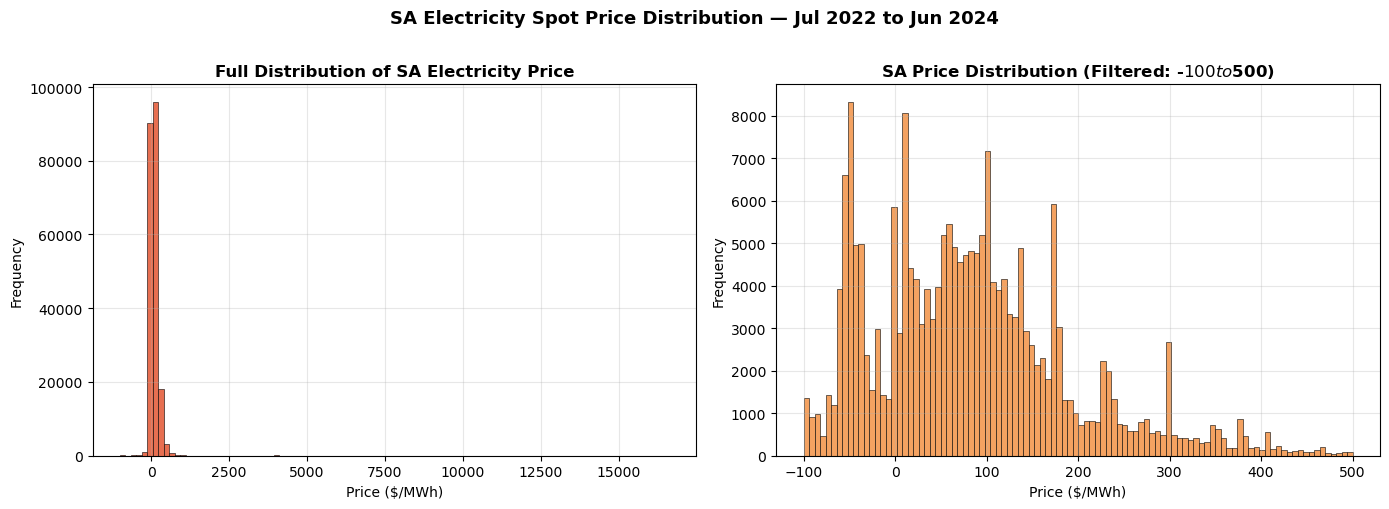

In [15]:
# VISUAL 1: Histogram — Distribution of SA Price (filtered)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full price distribution
axes[0].hist(df['SA1_Price'], bins=100, color='#e76f51',
             edgecolor='black', linewidth=0.4)
axes[0].set_title('Full Distribution of SA Electricity Price', fontweight='bold')
axes[0].set_xlabel('Price ($/MWh)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Filtered -100 to 500 for better readability
filtered = df[(df['SA1_Price'] >= -100) & (df['SA1_Price'] <= 500)]
axes[1].hist(filtered['SA1_Price'], bins=100, color='#f4a261',
             edgecolor='black', linewidth=0.4)
axes[1].set_title('SA Price Distribution (Filtered: -$100 to $500)', fontweight='bold')
axes[1].set_xlabel('Price ($/MWh)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.suptitle('SA Electricity Spot Price Distribution — Jul 2022 to Jun 2024',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_price_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

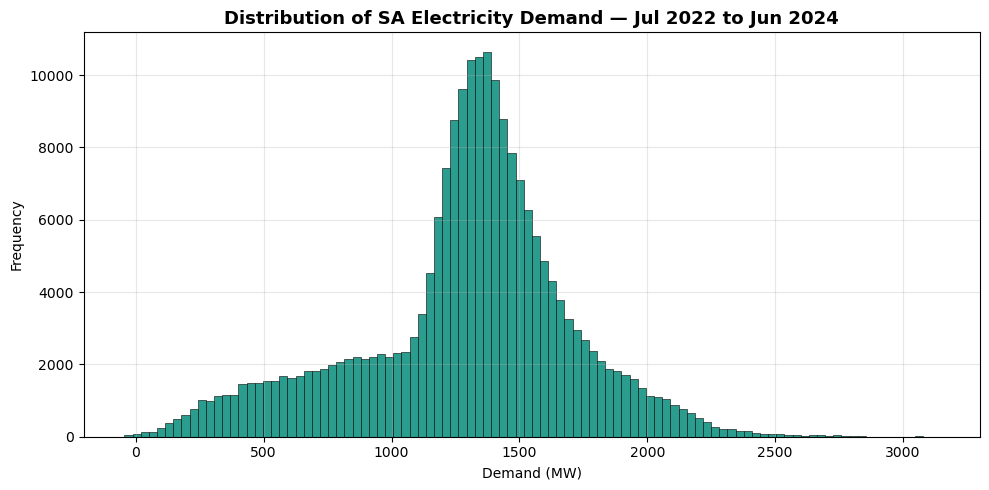

In [16]:
# VISUAL 2: Histogram — Distribution of SA Demand


plt.figure(figsize=(10, 5))
plt.hist(df['SA1_Demand'], bins=100, color='#2a9d8f',
         edgecolor='black', linewidth=0.4)
plt.title('Distribution of SA Electricity Demand — Jul 2022 to Jun 2024',
          fontsize=13, fontweight='bold')
plt.xlabel('Demand (MW)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_demand_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

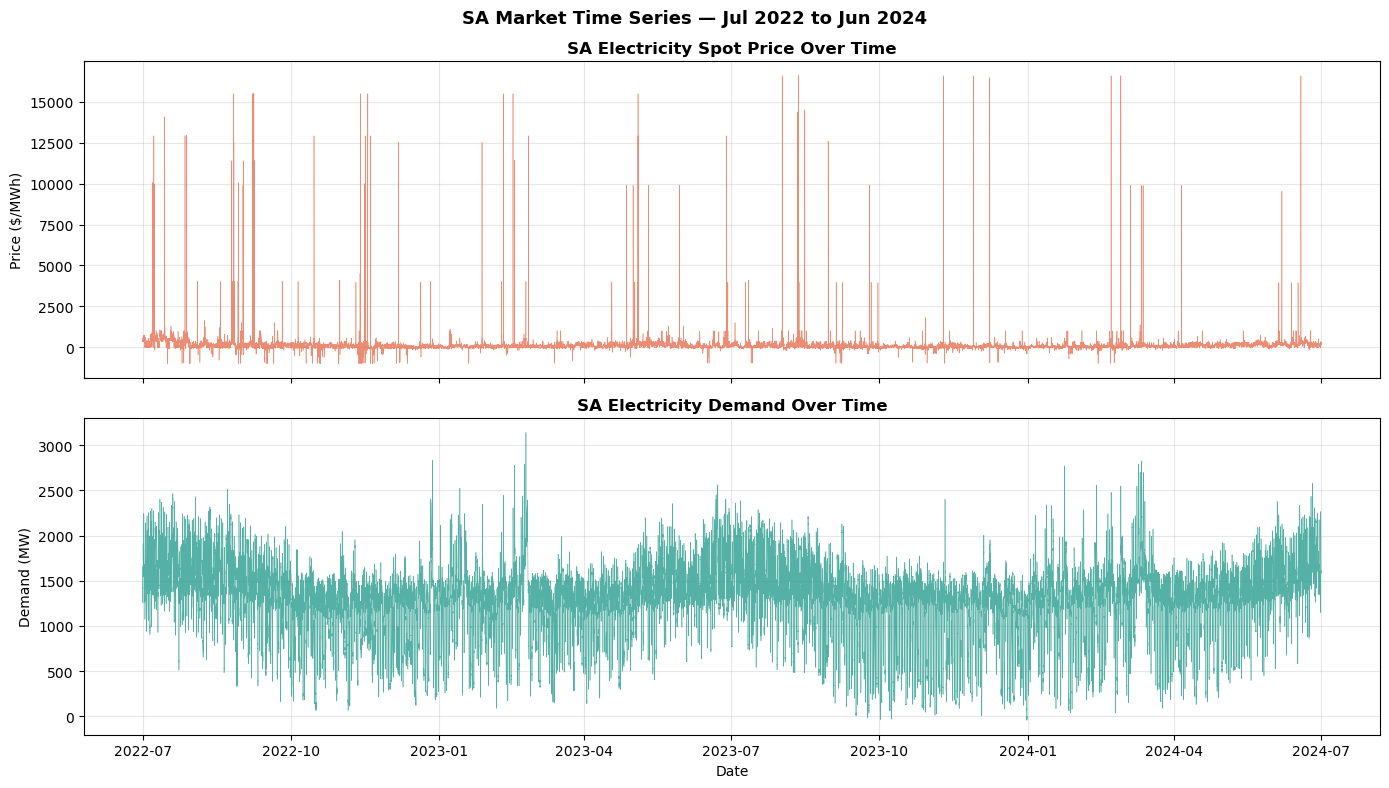

In [17]:
# VISUAL 3: Time Series — Price and Demand Over Time

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price time series
axes[0].plot(df['SETTLEMENTDATE'], df['SA1_Price'],
             color='#e76f51', linewidth=0.4, alpha=0.8)
axes[0].set_title('SA Electricity Spot Price Over Time', fontweight='bold')
axes[0].set_ylabel('Price ($/MWh)')
axes[0].grid(alpha=0.3)

# Demand time series
axes[1].plot(df['SETTLEMENTDATE'], df['SA1_Demand'],
             color='#2a9d8f', linewidth=0.4, alpha=0.8)
axes[1].set_title('SA Electricity Demand Over Time', fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.3)

plt.suptitle('SA Market Time Series — Jul 2022 to Jun 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

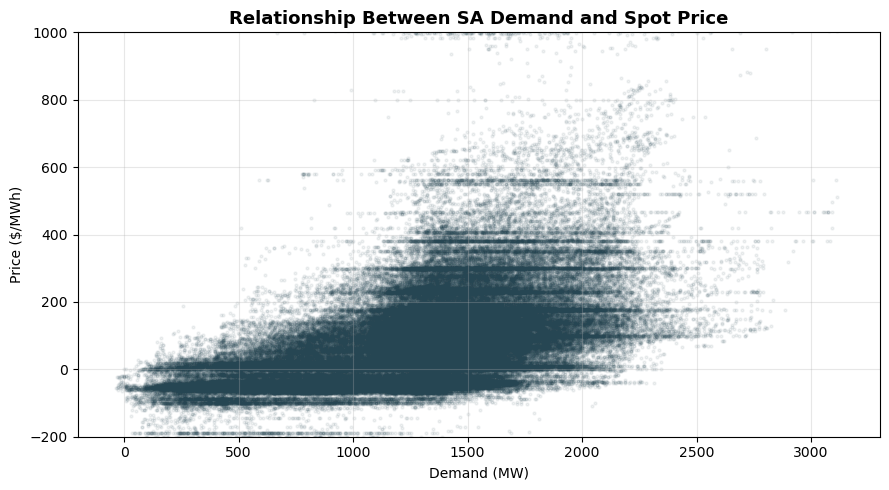

In [18]:
# VISUAL 4: Scatter Plot — Demand vs Price

plt.figure(figsize=(9, 5))
plt.scatter(df['SA1_Demand'], df['SA1_Price'],
            alpha=0.07, s=4, color='#264653')
plt.title('Relationship Between SA Demand and Spot Price',
          fontsize=13, fontweight='bold')
plt.xlabel('Demand (MW)')
plt.ylabel('Price ($/MWh)')
plt.ylim(-200, 1000)   # clip extreme spikes for readability
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation between Price and Demand: 0.2088


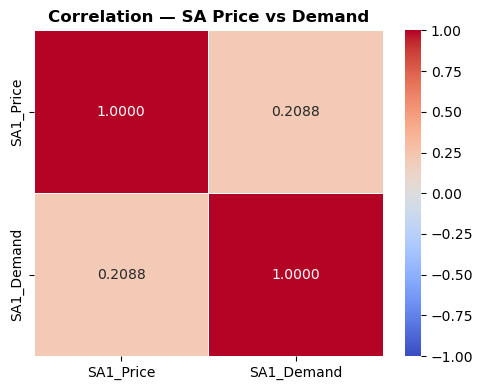

In [19]:
# VISUAL 5: Correlation Heatmap

corr_val = df[['SA1_Price', 'SA1_Demand']].corr()
print(f"Correlation between Price and Demand: {corr_val.iloc[0,1]:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(corr_val, annot=True, fmt='.4f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation — SA Price vs Demand', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:

# Nonlinear price-demand relationship 

print("Correlation by demand quartile:")
quartiles = pd.qcut(df['SA1_Demand'], q=4,
                    labels=['Q1 (0-25%)', 'Q2 (25-50%)',
                            'Q3 (50-75%)', 'Q4 (75-100%)'])
for q in quartiles.unique().sort_values():
    mask = quartiles == q
    corr = df.loc[mask, 'SA1_Price'].corr(df.loc[mask, 'SA1_Demand'])
    print(f"  {q}: r = {corr:.4f}")

Correlation by demand quartile:
  Q1 (0-25%): r = 0.1739
  Q2 (25-50%): r = 0.0462
  Q3 (50-75%): r = 0.0352
  Q4 (75-100%): r = 0.1043


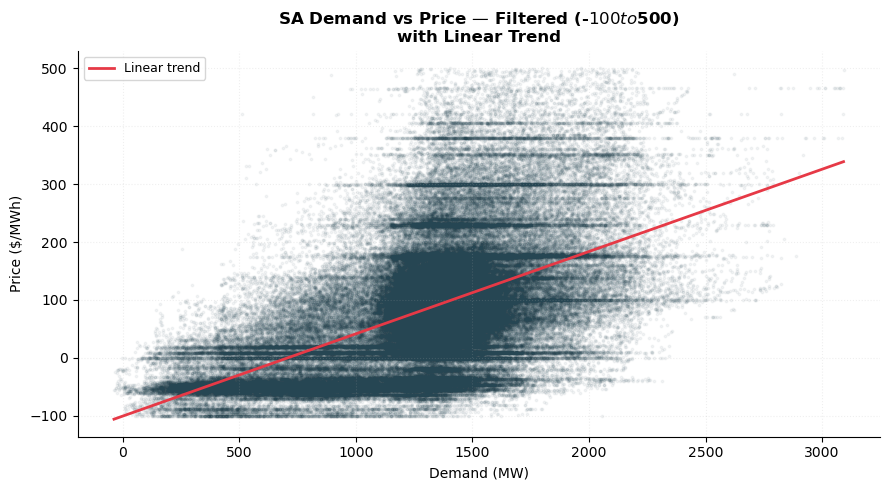

In [21]:
# Filtered version shows demand-price relationship clearly

fig, ax = plt.subplots(figsize=(9, 5))
filtered = df[(df['SA1_Price'] >= -100) & (df['SA1_Price'] <= 500)]

ax.scatter(filtered['SA1_Demand'], filtered['SA1_Price'],
           alpha=0.05, s=3, color='#264653')

# Add linear trend line
z = np.polyfit(filtered['SA1_Demand'], filtered['SA1_Price'], 1)
p = np.poly1d(z)
x_line = np.linspace(filtered['SA1_Demand'].min(),
                     filtered['SA1_Demand'].max(), 200)
ax.plot(x_line, p(x_line), color='#e63946',
        linewidth=2, label='Linear trend')

ax.set_xlabel('Demand (MW)', fontsize=10)
ax.set_ylabel('Price ($/MWh)', fontsize=10)
ax.set_title('SA Demand vs Price — Filtered (-$100 to $500)\nwith Linear Trend',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.2, linestyle=':')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('scatter_demand_price_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
#  DISPATCH-WEIGHTED CAPTURE PRICES
# Formula: DWP = Σ(P_t × Q_t) / Σ(Q_t)

print("DISPATCH-WEIGHTED CAPTURE PRICES")

# Calculate DWP for each individual generator
dwp_gen = {}
for gen in all_gens:
    total_Q = df[gen].sum()
    if total_Q > 0:
        dwp_gen[gen] = (df[price_col] * df[gen]).sum() / total_Q
    else:
        dwp_gen[gen] = np.nan

dwp_series = pd.Series(dwp_gen)

dwp_df = pd.DataFrame({
    'Generator':  dwp_series.index,
    'Technology': [tech_map[g] for g in dwp_series.index],
    'DWP_$/MWh':  dwp_series.values
}).dropna().sort_values('DWP_$/MWh', ascending=False).reset_index(drop=True)

print("\nCapture Price by Generator ($/MWh):")
print(dwp_df.to_string(index=False))

DISPATCH-WEIGHTED CAPTURE PRICES

Capture Price by Generator ($/MWh):
                   Generator Technology   DWP_$/MWh
          STANVAC_SA1_Diesel     Diesel 1046.042853
         ANGASTON_SA1_Diesel     Diesel  823.676049
         LONSDALE_SA1_Diesel     Diesel  804.547412
      AGLHAL_SA1_Natural Gas        Gas  457.302884
HORNSDPR_SA1_Battery Storage    Battery  407.526768
 BOLIVAR_SA1_Battery Storage    Battery  368.277316
     ADP_SA1_Battery Storage    Battery  313.277282
     BARKIPS_SA1_Natural Gas        Gas  261.941907
    QUARANTN_SA1_Natural Gas        Gas  250.025043
           CATHROCK_SA1_Wind       Wind   91.940420
          STARFHILL_SA1_Wind       Wind   84.914371
           CLEMGPWF_SA1_Wind       Wind   62.532505
             MAPS2_SA1_Solar      Solar   52.182045
              HVWW_SA1_Solar      Solar   46.857930
            BNGSF1_SA1_Solar      Solar   41.553680


In [23]:
# Aggregate DWP at technology level — creates tech_dwp_series

tech_dwp = {}
for tech, gens in gen_cols.items():
    total_Q = df[gens].sum(axis=1)
    tech_dwp[tech] = (df[price_col] * total_Q).sum() / total_Q.sum()

tech_dwp_series = pd.Series(tech_dwp).sort_values(ascending=False)

print("Capture Price by Technology ($/MWh):")
print(tech_dwp_series.round(2))

Capture Price by Technology ($/MWh):
Diesel     900.33
Battery    397.95
Gas        281.71
Wind        77.53
Solar       42.48
dtype: float64


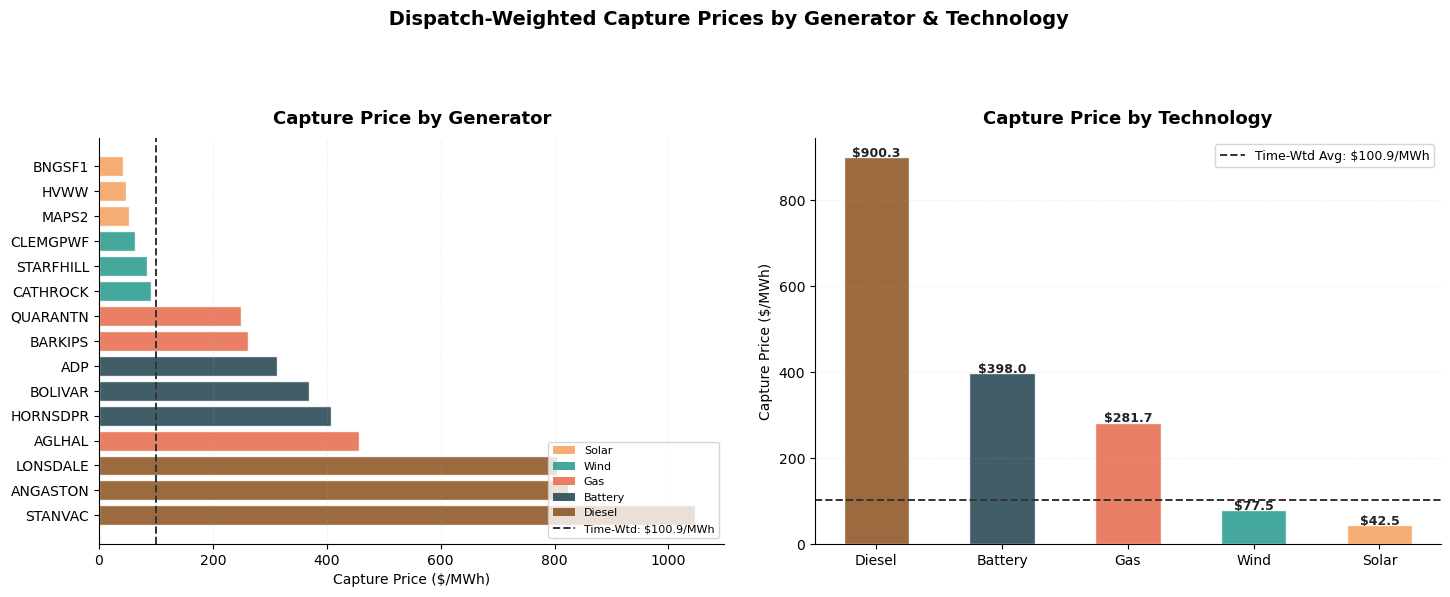

In [52]:
# VISUALISATION - 1

TITLE_SIZE  = 13
LABEL_SIZE  = 10
TICK_SIZE   = 9
BAR_ALPHA   = 0.88

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('white')

# ── Left: per-generator horizontal bar ──
bar_colors_gen = [colors_tech[tech_map[g]] for g in dwp_df['Generator']]
short_names    = dwp_df['Generator'].str.replace('_SA1.*', '', regex=True)

axes[0].barh(short_names, dwp_df['DWP_$/MWh'],
             color=bar_colors_gen, alpha=BAR_ALPHA, edgecolor='white')
axes[0].axvline(df[price_col].mean(), color='#333333',
                linestyle='--', linewidth=1.4,
                label=f"Time-Wtd Avg: ${df[price_col].mean():.1f}/MWh")
axes[0].set_xlabel('Capture Price ($/MWh)', fontsize=LABEL_SIZE)
axes[0].set_title('Capture Price by Generator', fontweight='bold',
                  fontsize=TITLE_SIZE, pad=10)
axes[0].grid(axis='x', alpha=0.25, linestyle=':')
axes[0].spines[['top','right']].set_visible(False)

# Combined legend: technology colours + benchmark line
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=colors_tech[t], label=t, alpha=BAR_ALPHA)
                for t in gen_cols]
legend_elems.append(
    plt.Line2D([0]l=f"Time-Wtd: ${df[price_col].mean():.1f}/MWh")
)
axes[0].legend(handles=legend_elems, fontsize=8, loc='lower right')

# ── Right: per-technology bar ──
tc = [colors_tech[t] for t in tech_dwp_series.index]
axes[1].bar(tech_dwp_series.index, tech_dwp_series.values,
            color=tc, alpha=BAR_ALPHA, width=0.52, edgecolor='white')
axes[1].axhline(df[price_col].mean(), color='#333333',
                linestyle='--', linewidth=1.4,
                label=f"Time-Wtd Avg: ${df[price_col].mean():.1f}/MWh")
axes[1].set_ylabel('Capture Price ($/MWh)', fontsize=LABEL_SIZE)
axes[1].set_title('Capture Price by Technology', fontweight='bold',
                  fontsize=TITLE_SIZE, pad=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.25, linestyle=':')
axes[1].spines[['top','right']].set_visible(False)

for i, (t, v) in enumerate(tech_dwp_series.items()):
    axes[1].text(i, v + 1.5, f'${v:.1f}', ha='center',
                 fontsize=9, fontweight='bold', color='#222222')

fig.suptitle(' Dispatch-Weighted Capture Prices by Generator & Technology',
             fontsize=TITLE_SIZE + 1, fontweight='bold', y=1.02)
plt.tight_layout(pad=2.5)
plt.savefig('q1_capture_prices.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# DWP vs TIME-WEIGHTED vs VOLUME-WEIGHTED

print("=" * 60)
print("Q2 — CAPTURE PRICE vs MARKET BENCHMARK PRICES")
print("=" * 60)

twp = df[price_col].mean()
vwp = (df[price_col] * df['SA1_Demand']).sum() / df['SA1_Demand'].sum()

print(f"\nTime-Weighted Market Price:   ${twp:.2f}/MWh")
print(f"Volume-Weighted Market Price: ${vwp:.2f}/MWh")

Q2 — CAPTURE PRICE vs MARKET BENCHMARK PRICES

Time-Weighted Market Price:   $100.88/MWh
Volume-Weighted Market Price: $128.79/MWh


In [26]:
# Comparison table per technology
comp = pd.DataFrame({
    'Capture Price ($/MWh)':    tech_dwp_series,
    'Diff vs Time-Wtd ($/MWh)': tech_dwp_series - twp,
    'Diff vs Vol-Wtd ($/MWh)':  tech_dwp_series - vwp,
})
print("Capture Price vs Benchmark Comparison:")
print(comp.round(2))

Capture Price vs Benchmark Comparison:
         Capture Price ($/MWh)  Diff vs Time-Wtd ($/MWh)  \
Diesel                  900.33                    799.46   
Battery                 397.95                    297.08   
Gas                     281.71                    180.83   
Wind                     77.53                    -23.34   
Solar                    42.48                    -58.39   

         Diff vs Vol-Wtd ($/MWh)  
Diesel                    771.54  
Battery                   269.16  
Gas                       152.91  
Wind                      -51.26  
Solar                     -86.31  


In [27]:
# Annual benchmarks by financial year
print("Annual Benchmark Prices by Financial Year:")
for fy in sorted(df['FY'].unique()):
    sub     = df[df['FY'] == fy]
    twp_fy  = sub[price_col].mean()
    vwp_fy  = (sub[price_col] * sub['SA1_Demand']).sum() / sub['SA1_Demand'].sum()
    print(f"  {fy}:  Time-Wtd = ${twp_fy:.2f}/MWh  |  "
          f"Volume-Wtd = ${vwp_fy:.2f}/MWh")

Annual Benchmark Prices by Financial Year:
  FY2022/23:  Time-Wtd = $123.25/MWh  |  Volume-Wtd = $151.87/MWh
  FY2023/24:  Time-Wtd = $78.56/MWh  |  Volume-Wtd = $104.80/MWh


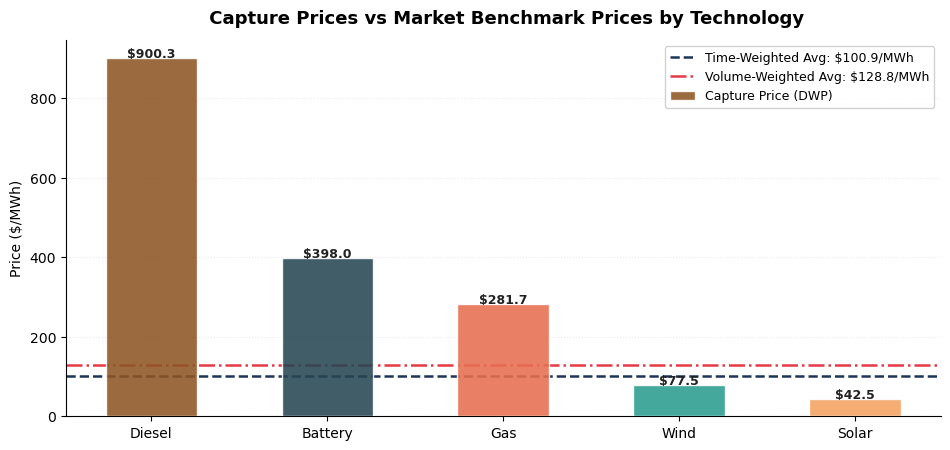

In [53]:
# VISUALISATION - 2

x   = np.arange(len(tech_dwp_series))
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

ax.bar(x, tech_dwp_series.values,
       color=[colors_tech[t] for t in tech_dwp_series.index],
       width=0.52, alpha=BAR_ALPHA, edgecolor='white',
       label='Capture Price (DWP)', zorder=3)

ax.axhline(twp, color='#1d3557', linestyle='--',
           linewidth=1.8, label=f'Time-Weighted Avg: ${twp:.1f}/MWh')
ax.axhline(vwp, color='#e63946', linestyle='-.',
           linewidth=1.8, label=f'Volume-Weighted Avg: ${vwp:.1f}/MWh')

ax.set_xticks(x)
ax.set_xticklabels(tech_dwp_series.index, fontsize=LABEL_SIZE)
ax.set_ylabel('Price ($/MWh)', fontsize=LABEL_SIZE)
ax.set_title(' Capture Prices vs Market Benchmark Prices by Technology',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(axis='y', alpha=0.25, linestyle=':', zorder=0)
ax.spines[['top','right']].set_visible(False)

for i, v in enumerate(tech_dwp_series.values):
    ax.text(i, v + 1.5, f'${v:.1f}', ha='center',
            fontsize=9, fontweight='bold', color='#222222')

plt.tight_layout(pad=2.5)
plt.savefig('q2_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# REVENUE BY TECHNOLOGY
# Revenue_t = Price_t ($/MWh) × Dispatch_t (MWh) * 5/60


print("=" * 60)
print("Q3 — REVENUE GENERATED BY TECHNOLOGY")
print("=" * 60)

# Per-generator revenue
for gen in all_gens:
    df[f'rev_{gen}'] = df[price_col] * df[gen] * (5/60)

for tech, gens in gen_cols.items():
    df[f'rev_{tech}'] = df[[f'rev_{g}' for g in gens]].sum(axis=1)

rev_cols = [f'rev_{t}' for t in gen_cols]
print("Revenue columns created with MW × (5/60) correction applied.")

Q3 — REVENUE GENERATED BY TECHNOLOGY
Revenue columns created with MW × (5/60) correction applied.


In [30]:
# Annual revenue ($M)
annual_rev = df.groupby('FY')[rev_cols].sum() / 1e6
annual_rev.columns = list(gen_cols.keys())
print("ANNUAL REVENUE ($M):")
print(annual_rev.round(2))

ANNUAL REVENUE ($M):
           Solar   Wind     Gas  Battery  Diesel
FY                                              
FY2022/23  13.98  35.86  178.92    13.01   12.84
FY2023/24   8.08  22.80  107.92    10.65    7.52


In [31]:
# Quarterly revenue ($M)
quarterly_rev = df.groupby('Quarter')[rev_cols].sum() / 1e6
quarterly_rev.columns = list(gen_cols.keys())
print("QUARTERLY REVENUE ($M):")
print(quarterly_rev.round(2))

QUARTERLY REVENUE ($M):
         Solar   Wind     Gas  Battery  Diesel
Quarter                                       
2022Q3    7.47  17.15  104.15     6.96    7.47
2022Q4    0.65   6.25   19.81     0.96    0.62
2023Q1    2.46   5.81   17.67     1.75    2.18
2023Q2    3.39   6.65   37.29     3.33    2.58
2023Q3    1.69   4.42   40.85     4.19    3.50
2023Q4    0.27   4.27    6.78     1.08    0.52
2024Q1    1.96   5.57   21.41     2.69    2.04
2024Q2    4.16   8.53   38.89     2.69    1.45


In [32]:
# Monthly revenue ($M)
monthly_rev = df.groupby('YearMonth')[rev_cols].sum() / 1e6
monthly_rev.columns = list(gen_cols.keys())
print("MONTHLY REVENUE ($M) — first 6 months shown:")
print(monthly_rev.head(6).round(2))

MONTHLY REVENUE ($M) — first 6 months shown:
           Solar  Wind    Gas  Battery  Diesel
YearMonth                                     
2022-07     4.40  9.21  50.80     3.13    5.69
2022-08     1.60  3.87  35.85     2.32    1.20
2022-09     1.47  4.07  17.50     1.51    0.57
2022-10     0.38  3.08  10.39     0.50    0.11
2022-11     0.82  1.56   7.76     0.25    0.50
2022-12    -0.54  1.61   1.66     0.21    0.00


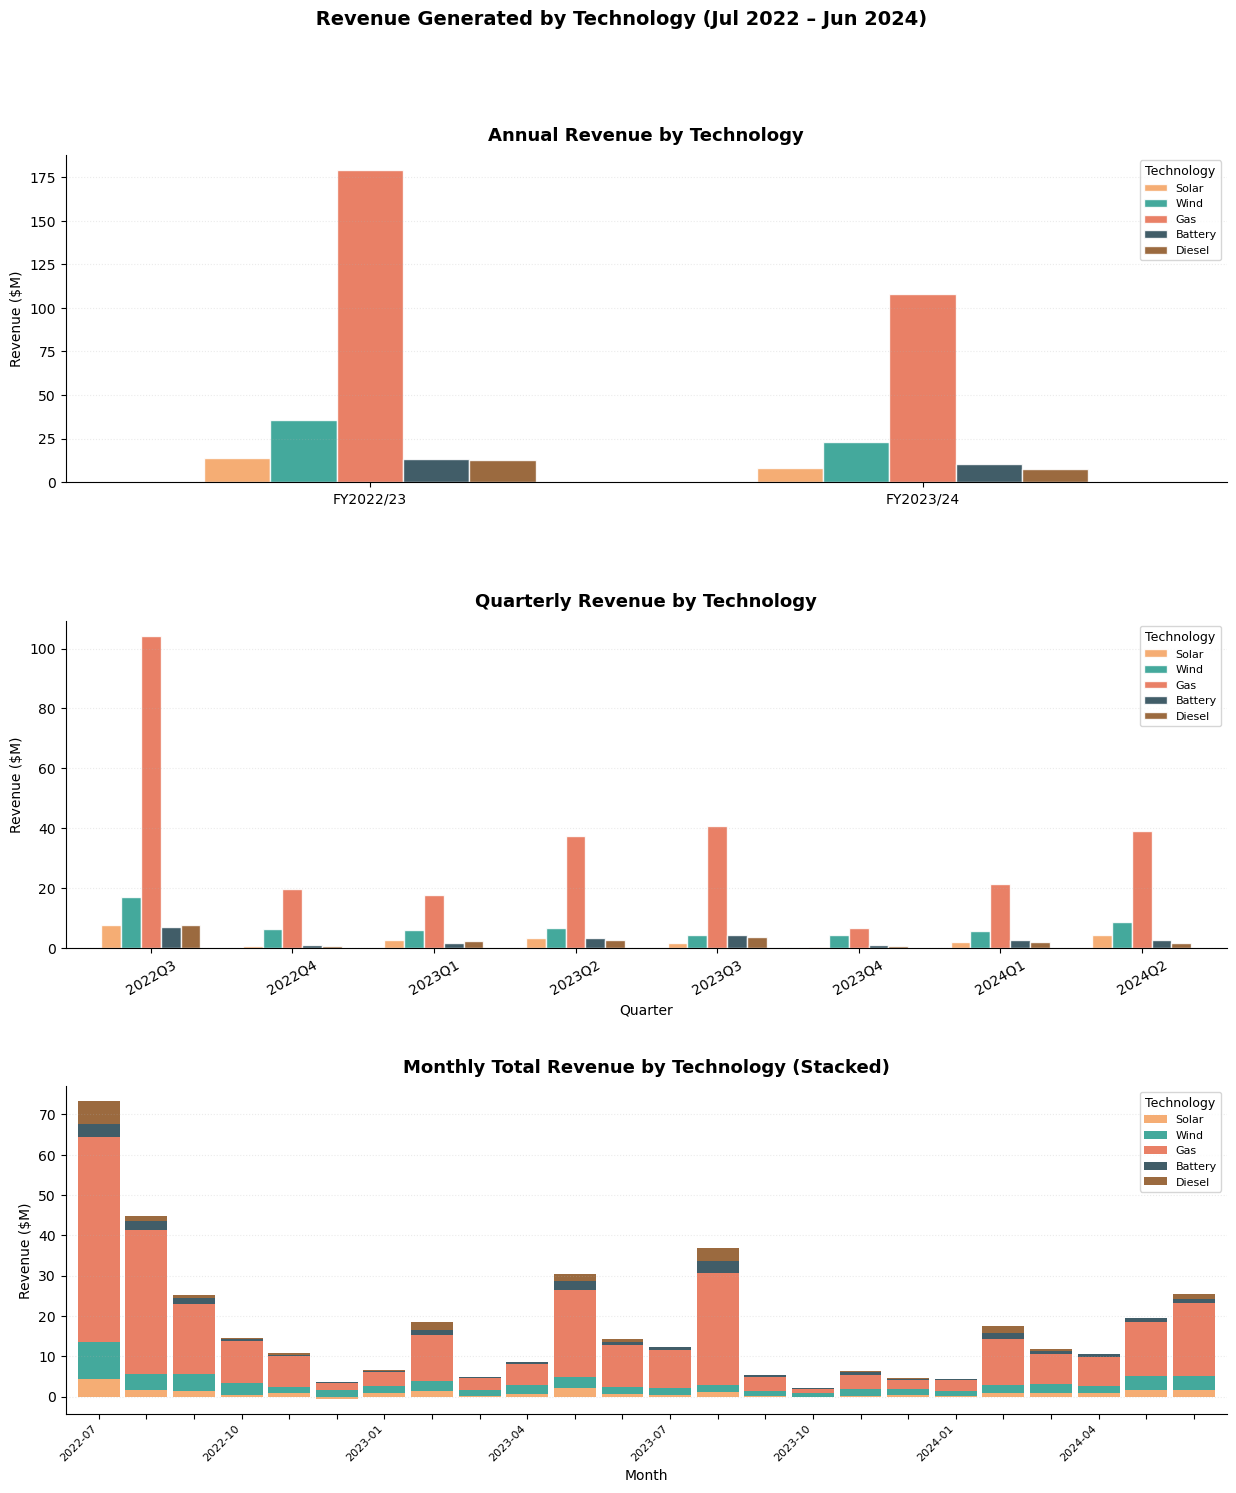

In [54]:
# VISUALISATION - 3

fig, axes = plt.subplots(3, 1, figsize=(13, 15))
fig.patch.set_facecolor('white')

tech_list  = list(gen_cols.keys())
bar_colors = [colors_tech[t] for t in tech_list]

# Panel 1 — Annual grouped bar
annual_rev.plot(kind='bar', ax=axes[0], color=bar_colors,
                width=0.6, alpha=BAR_ALPHA, edgecolor='white')
axes[0].set_title('Annual Revenue by Technology',
                  fontweight='bold', fontsize=TITLE_SIZE, pad=10)
axes[0].set_ylabel('Revenue ($M)', fontsize=LABEL_SIZE)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Technology', fontsize=8, title_fontsize=9)
axes[0].grid(axis='y', alpha=0.25, linestyle=':')
axes[0].spines[['top','right']].set_visible(False)

# Panel 2 — Quarterly grouped bar
quarterly_rev.plot(kind='bar', ax=axes[1], color=bar_colors,
                   width=0.7, alpha=BAR_ALPHA, edgecolor='white')
axes[1].set_title('Quarterly Revenue by Technology',
                  fontweight='bold', fontsize=TITLE_SIZE, pad=10)
axes[1].set_ylabel('Revenue ($M)', fontsize=LABEL_SIZE)
axes[1].set_xlabel('Quarter', fontsize=LABEL_SIZE)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Technology', fontsize=8, title_fontsize=9)
axes[1].grid(axis='y', alpha=0.25, linestyle=':')
axes[1].spines[['top','right']].set_visible(False)

# Panel 3 — Monthly stacked bar
monthly_rev.plot(kind='bar', stacked=True, ax=axes[2],
                 color=bar_colors, width=0.88,
                 alpha=BAR_ALPHA, edgecolor='none')
axes[2].set_title('Monthly Total Revenue by Technology (Stacked)',
                  fontweight='bold', fontsize=TITLE_SIZE, pad=10)
axes[2].set_ylabel('Revenue ($M)', fontsize=LABEL_SIZE)
axes[2].set_xlabel('Month', fontsize=LABEL_SIZE)
# Show only every 3rd month label to avoid crowding
labels = [str(p) if i % 3 == 0 else ''
          for i, p in enumerate(monthly_rev.index)]
axes[2].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[2].legend(title='Technology', fontsize=8, title_fontsize=9,
               loc='upper right')
axes[2].grid(axis='y', alpha=0.25, linestyle=':')
axes[2].spines[['top','right']].set_visible(False)

fig.suptitle(' Revenue Generated by Technology (Jul 2022 – Jun 2024)',
             fontsize=TITLE_SIZE + 1, fontweight='bold', y=1.01)
plt.tight_layout(pad=3.0)
plt.savefig('q3_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
#  REVENUE VARIABILITY
# Coefficient of Variation = Std/Mean × 100 (risk metric)

print("=" * 60)
print("Q4 — REVENUE VARIABILITY BY TECHNOLOGY")
print("=" * 60)

monthly_stats = pd.DataFrame({
    'Mean Rev ($M)': monthly_rev.mean(),
    'Std Dev ($M)':  monthly_rev.std(),
    'Min ($M)':      monthly_rev.min(),
    'Max ($M)':      monthly_rev.max(),
    'CoV (%)':       monthly_rev.std() / monthly_rev.mean().abs() * 100
})
print("Monthly Revenue Statistics by Technology:")
print(monthly_stats.round(2))

Q4 — REVENUE VARIABILITY BY TECHNOLOGY
Monthly Revenue Statistics by Technology:
         Mean Rev ($M)  Std Dev ($M)  Min ($M)  Max ($M)  CoV (%)
Solar             0.92          0.99     -0.54      4.40   107.51
Wind              2.44          1.68      0.83      9.21    68.57
Gas              11.95         12.01      1.04     50.80   100.45
Battery           0.99          0.89      0.19      3.13    90.60
Diesel            0.85          1.31      0.00      5.69   154.77


In [35]:
quarterly_stats = pd.DataFrame({
    'Mean Rev ($M)': quarterly_rev.mean(),
    'Std Dev ($M)':  quarterly_rev.std(),
    'CoV (%)':       quarterly_rev.std() / quarterly_rev.mean().abs() * 100
})
print("Quarterly Revenue Statistics by Technology:")
print(quarterly_stats.round(2))

Quarterly Revenue Statistics by Technology:
         Mean Rev ($M)  Std Dev ($M)  CoV (%)
Solar             2.76          2.30    83.52
Wind              7.33          4.19    57.12
Gas              35.85         30.10    83.96
Battery           2.96          1.96    66.13
Diesel            2.55          2.22    87.35


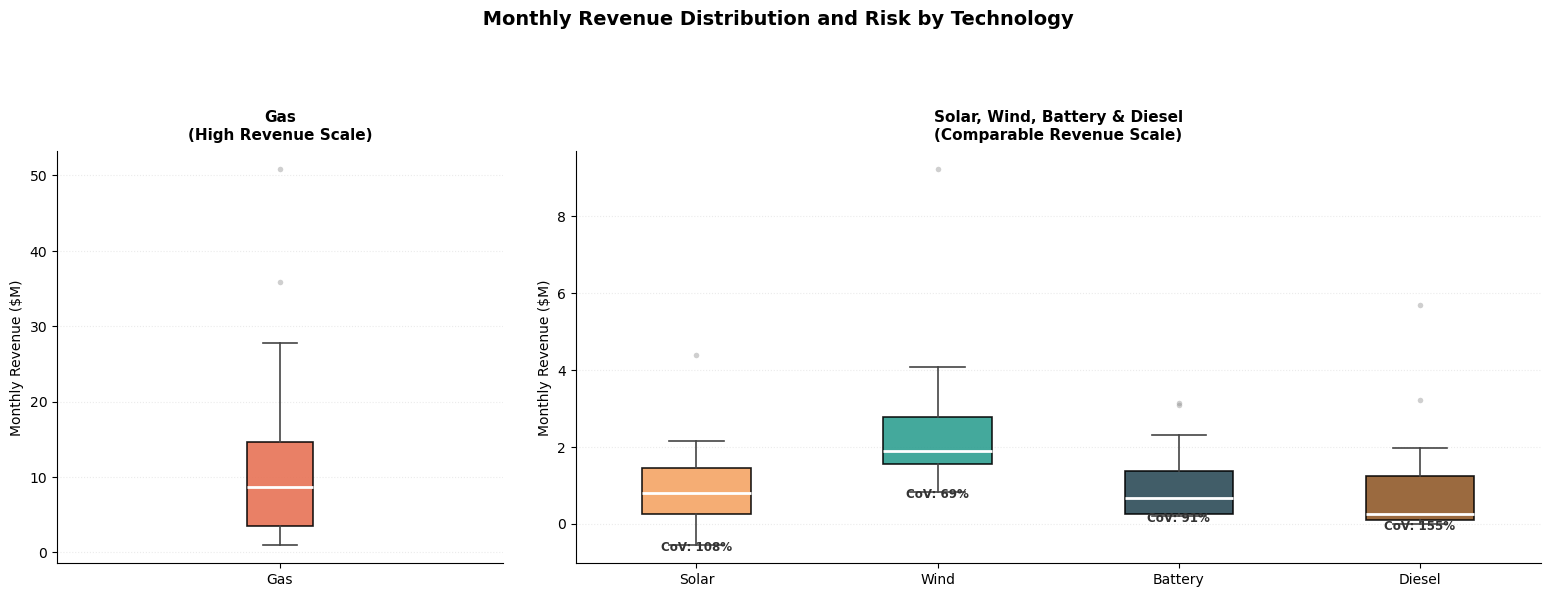

In [55]:
# VISUALISATION — 4


TITLE_SIZE = 13
LABEL_SIZE = 10
BAR_ALPHA  = 0.88
tech_list  = list(gen_cols.keys())

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor('white')

# ── Panel 1 (left): Boxplot — Gas only (large scale) ──────────
ax1 = fig.add_subplot(1, 3, 1)
bp1 = ax1.boxplot(
    [monthly_rev['Gas'].values],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#444444', linewidth=1.2),
    capprops=dict(color='#444444', linewidth=1.2),
    flierprops=dict(marker='o', markersize=4,
                    alpha=0.4, markerfacecolor='#888888',
                    markeredgecolor='none'),
    boxprops=dict(linewidth=1.2)
)
bp1['boxes'][0].set_facecolor(colors_tech['Gas'])
bp1['boxes'][0].set_alpha(BAR_ALPHA)
ax1.set_xticklabels(['Gas'])
ax1.set_title('Gas\n(High Revenue Scale)',
              fontweight='bold', fontsize=11, pad=8)
ax1.set_ylabel('Monthly Revenue ($M)', fontsize=LABEL_SIZE)
ax1.grid(axis='y', alpha=0.25, linestyle=':')
ax1.spines[['top', 'right']].set_visible(False)

# ── Panel 2 (right 2/3): Boxplot — all others ─────────────────
ax2 = fig.add_subplot(1, 3, (2, 3))
other_techs = ['Solar', 'Wind', 'Battery', 'Diesel']
data_others = [monthly_rev[t].values for t in other_techs]

bp2 = ax2.boxplot(
    data_others,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#444444', linewidth=1.2),
    capprops=dict(color='#444444', linewidth=1.2),
    flierprops=dict(marker='o', markersize=4,
                    alpha=0.4, markerfacecolor='#888888',
                    markeredgecolor='none'),
    boxprops=dict(linewidth=1.2)
)
for patch, tech in zip(bp2['boxes'], other_techs):
    patch.set_facecolor(colors_tech[tech])
    patch.set_alpha(BAR_ALPHA)

ax2.set_xticks(range(1, len(other_techs) + 1))
ax2.set_xticklabels(other_techs, fontsize=LABEL_SIZE)
ax2.set_title('Solar, Wind, Battery & Diesel\n(Comparable Revenue Scale)',
              fontweight='bold', fontsize=11, pad=8)
ax2.set_ylabel('Monthly Revenue ($M)', fontsize=LABEL_SIZE)
ax2.grid(axis='y', alpha=0.25, linestyle=':')
ax2.spines[['top', 'right']].set_visible(False)

# Add CoV annotations below each box in panel 2
cov_others = {t: monthly_stats.loc[t, 'CoV (%)'] for t in other_techs}
for i, tech in enumerate(other_techs):
    ax2.text(i + 1, monthly_rev[tech].min() - 0.15,
             f'CoV: {cov_others[tech]:.0f}%',
             ha='center', fontsize=8.5, color='#333333', fontweight='bold')

fig.suptitle(' Monthly Revenue Distribution and Risk by Technology',
             fontsize=TITLE_SIZE + 1, fontweight='bold', y=1.02)
plt.tight_layout(pad=2.5)
plt.savefig('q4_boxplot_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

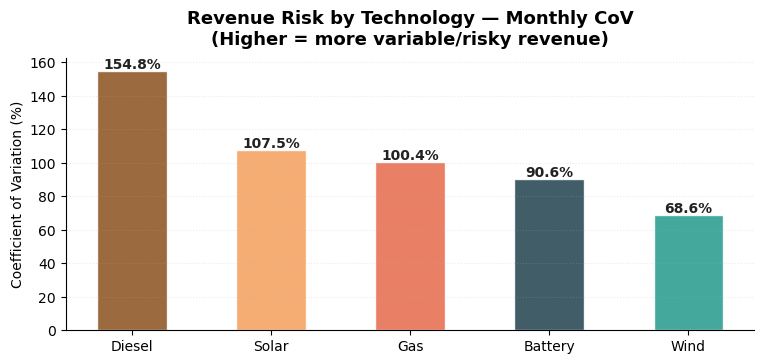

In [37]:
#  CoV Bar Chart 

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white')

cov_vals = monthly_stats['CoV (%)'].sort_values(ascending=False)
colors_cov = [colors_tech[t] for t in cov_vals.index]

bars = ax.bar(cov_vals.index, cov_vals.values,
              color=colors_cov, width=0.5,
              alpha=BAR_ALPHA, edgecolor='white')

ax.set_ylabel('Coefficient of Variation (%)', fontsize=LABEL_SIZE)
ax.set_title('Revenue Risk by Technology — Monthly CoV\n'
             '(Higher = more variable/risky revenue)',
             fontweight='bold', fontsize=TITLE_SIZE, pad=10)
ax.grid(axis='y', alpha=0.25, linestyle=':')
ax.spines[['top', 'right']].set_visible(False)

for i, (tech, v) in enumerate(cov_vals.items()):
    ax.text(i, v + 1.5, f'{v:.1f}%',
            ha='center', fontsize=10,
            fontweight='bold', color='#222222')

plt.tight_layout(pad=2)
plt.savefig('q4_cov.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# CAPACITY FACTORS
# CF = Actual MWh / (Installed Capacity MW × Total Hours)


print("=" * 60)
print("Q5 — CAPACITY FACTORS BY GENERATOR & TECHNOLOGY")
print("=" * 60)

installed_MW = {
    'MAPS2_SA1_Solar':                 1.2,
    'BNGSF1_SA1_Solar':              137.9,
    'HVWW_SA1_Solar':                  1.0,
    'CLEMGPWF_SA1_Wind':              57.0,
    'CATHROCK_SA1_Wind':              66.0,
    'STARFHILL_SA1_Wind':             34.5,
    'BARKIPS_SA1_Natural Gas':       210.0,
    'AGLHAL_SA1_Natural Gas':        203.0,
    'QUARANTN_SA1_Natural Gas':      240.0,
    'HORNSDPR_SA1_Battery Storage':  150.0,
    'BOLIVAR_SA1_Battery Storage':    10.0,
    'ADP_SA1_Battery Storage':         5.0,
    'ANGASTON_SA1_Diesel':            50.0,
    'LONSDALE_SA1_Diesel':            50.0,
    'STANVAC_SA1_Diesel':             50.0,
}

total_hours = ((df['SETTLEMENTDATE'].max()
                - df['SETTLEMENTDATE'].min()).total_seconds() / 3600)
print(f"Total hours in dataset: {total_hours:.0f} hrs")

Q5 — CAPACITY FACTORS BY GENERATOR & TECHNOLOGY
Total hours in dataset: 17544 hrs


In [39]:
# Capacity Factor per generator
# actual MWh = sum of MW dispatch × (5/60) per interval

cf_data = []
for gen in all_gens:
    actual_MWh = df[gen].sum() * (5/60)          # ← KEY FIX
    cap_MW     = installed_MW.get(gen, np.nan)
    max_MWh    = cap_MW * total_hours
    cf         = (actual_MWh / max_MWh * 100) if max_MWh > 0 else np.nan
    cf_data.append({
        'Generator':    gen,
        'Technology':   tech_map[gen],
        'Installed MW': cap_MW,
        'Actual MWh':   round(actual_MWh, 0),
        'CF (%)':       round(cf, 2)
    })

cf_df = pd.DataFrame(cf_data).sort_values('CF (%)', ascending=False)
print("Capacity Factors by Generator:")
print(cf_df.to_string(index=False))

Capacity Factors by Generator:
                   Generator Technology  Installed MW  Actual MWh  CF (%)
             MAPS2_SA1_Solar      Solar           1.2     38066.0  180.81
              HVWW_SA1_Solar      Solar           1.0     14853.0   84.66
           CLEMGPWF_SA1_Wind       Wind          57.0    335870.0   33.59
          STARFHILL_SA1_Wind       Wind          34.5    145539.0   24.05
           CATHROCK_SA1_Wind       Wind          66.0    275094.0   23.76
            BNGSF1_SA1_Solar      Solar         137.9    466161.0   19.27
     BARKIPS_SA1_Natural Gas        Gas         210.0    572906.0   15.55
    QUARANTN_SA1_Natural Gas        Gas         240.0    322635.0    7.66
     ADP_SA1_Battery Storage    Battery           5.0      5561.0    6.34
      AGLHAL_SA1_Natural Gas        Gas         203.0    122687.0    3.44
HORNSDPR_SA1_Battery Storage    Battery         150.0     52740.0    2.00
         ANGASTON_SA1_Diesel     Diesel          50.0      8451.0    0.96
       

In [40]:
# Technology-level CF 

tech_cf = {}
for tech, gens in gen_cols.items():
    actual  = df[gens].sum().sum() * (5/60)       # ← KEY FIX
    max_MWh = sum(installed_MW[g] for g in gens) * total_hours
    tech_cf[tech] = round(actual / max_MWh * 100, 2)

tech_cf_series = pd.Series(tech_cf).sort_values(ascending=False)
print("Capacity Factors by Technology (%):")
print(tech_cf_series)

Capacity Factors by Technology (%):
Wind       27.38
Solar      21.12
Gas         8.89
Battery     2.05
Diesel      0.86
dtype: float64


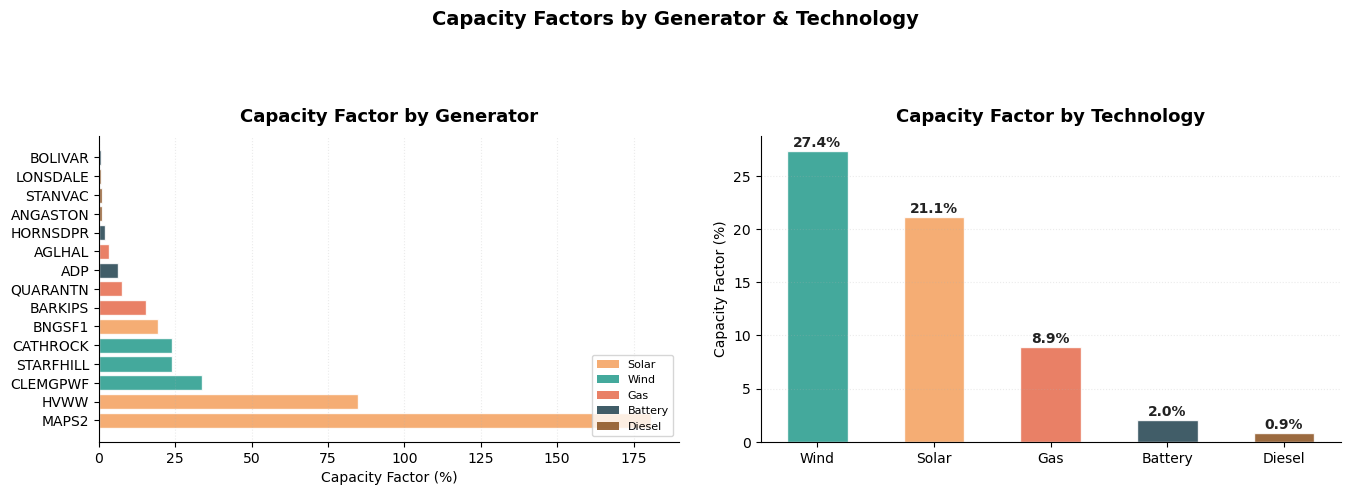

In [56]:
# VISUALISATION ─ 5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# Left — per-generator horizontal bar
bar_c = [colors_tech[tech_map[g]] for g in cf_df['Generator']]
short = cf_df['Generator'].str.replace('_SA1.*', '', regex=True)

axes[0].barh(short, cf_df['CF (%)'],
             color=bar_c, alpha=BAR_ALPHA, edgecolor='white')
axes[0].set_xlabel('Capacity Factor (%)', fontsize=LABEL_SIZE)
axes[0].set_title('Capacity Factor by Generator',
                  fontweight='bold', fontsize=TITLE_SIZE, pad=10)
axes[0].grid(axis='x', alpha=0.25, linestyle=':')
axes[0].spines[['top','right']].set_visible(False)
legend_elems = [Patch(facecolor=colors_tech[t], label=t, alpha=BAR_ALPHA)
                for t in gen_cols]
axes[0].legend(handles=legend_elems, fontsize=8, loc='lower right')

# Right — per-technology bar
tc = [colors_tech[t] for t in tech_cf_series.index]
axes[1].bar(tech_cf_series.index, tech_cf_series.values,
            color=tc, alpha=BAR_ALPHA, width=0.52, edgecolor='white')
axes[1].set_ylabel('Capacity Factor (%)', fontsize=LABEL_SIZE)
axes[1].set_title('Capacity Factor by Technology',
                  fontweight='bold', fontsize=TITLE_SIZE, pad=10)
axes[1].grid(axis='y', alpha=0.25, linestyle=':')
axes[1].spines[['top','right']].set_visible(False)
for i, (t, v) in enumerate(tech_cf_series.items()):
    axes[1].text(i, v + 0.4, f'{v:.1f}%', ha='center',
                 fontsize=10, fontweight='bold', color='#222222')

fig.suptitle('Capacity Factors by Generator & Technology',
             fontsize=TITLE_SIZE + 1, fontweight='bold', y=1.02)
plt.tight_layout(pad=2.5)
plt.savefig('q5_capacity_factors.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# INTRA-DAILY PATTERNS

print("=" * 60)
print("Q6 — INTRA-DAILY DISPATCH & PRICE PATTERNS")
print("=" * 60)

intraday_dispatch = {}
for tech, gens in gen_cols.items():
    intraday_dispatch[tech] = df.groupby('interval')[gens].mean().sum(axis=1)

price_intraday = df.groupby('interval')['SA1_Price'].agg(['mean','median'])
hour_axis      = np.arange(288) * 5 / 60

Q6 — INTRA-DAILY DISPATCH & PRICE PATTERNS


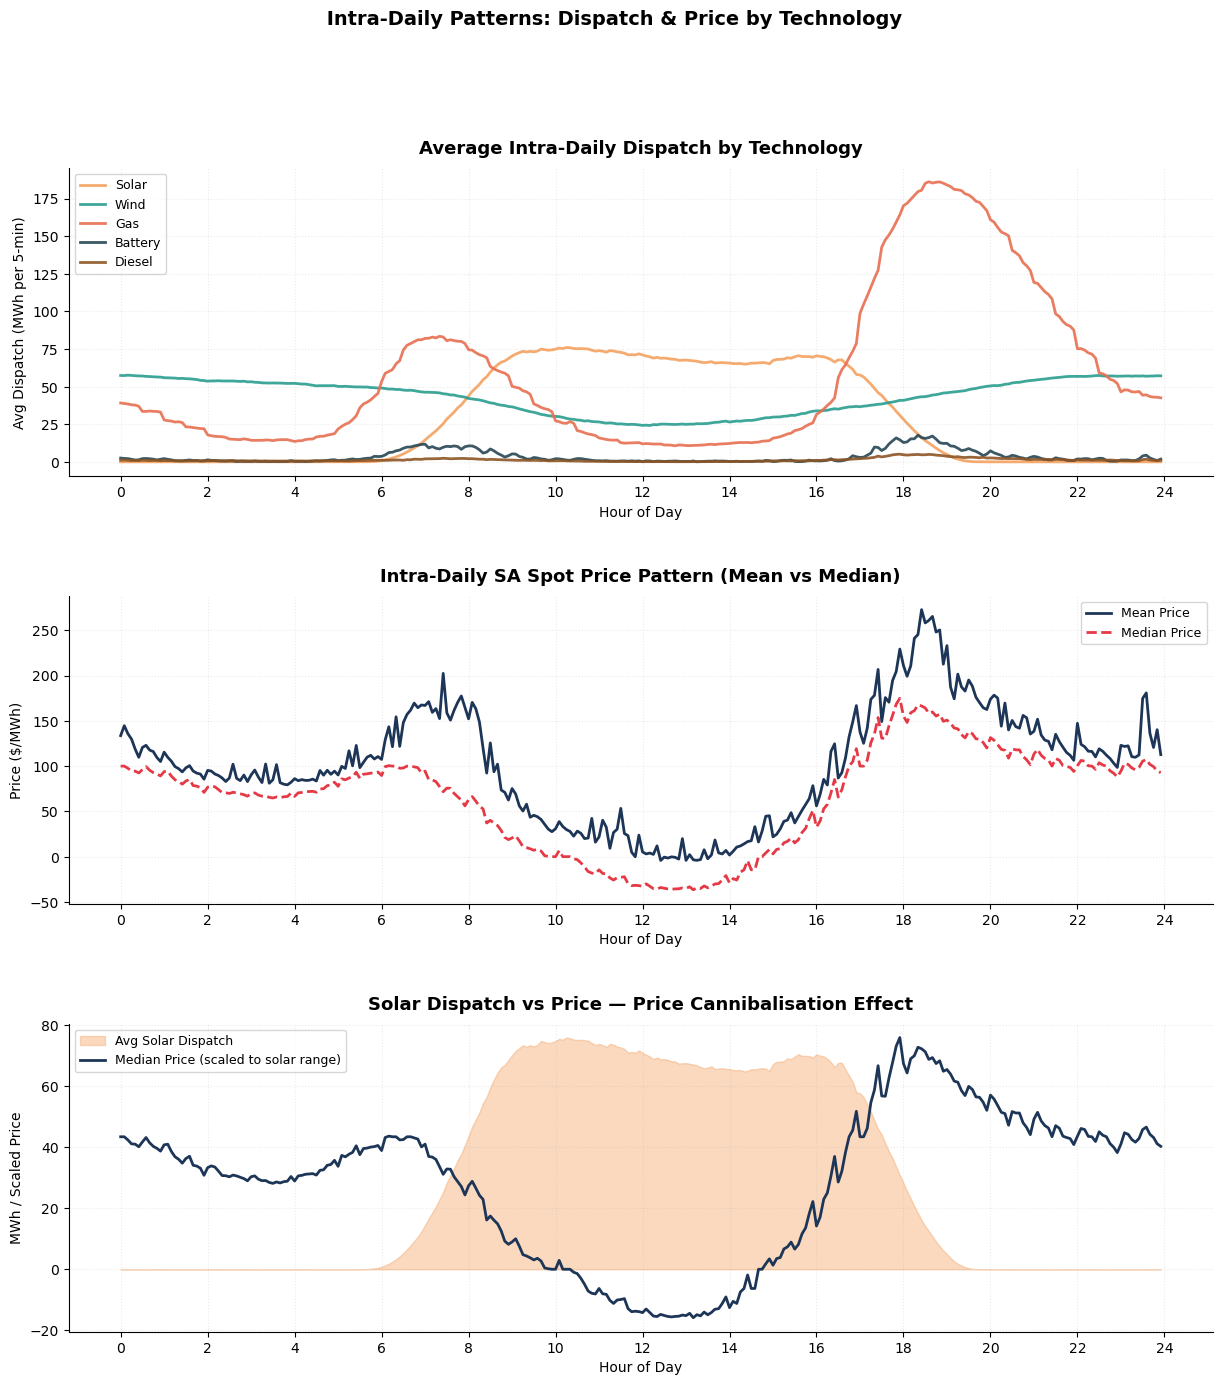

In [58]:
# VISUALISATION ─ 6

fig, axes = plt.subplots(3, 1, figsize=(13, 14))
fig.patch.set_facecolor('white')

# Panel 1 — Intra-daily dispatch by technology
for tech, series in intraday_dispatch.items():
    axes[0].plot(hour_axis, series.values,
                 label=tech, color=colors_tech[tech],
                 linewidth=2.0, alpha=0.9)
axes[0].set_title('Average Intra-Daily Dispatch by Technology',
                  fontweight='bold', fontsize=TITLE_SIZE, pad=10)
axes[0].set_ylabel('Avg Dispatch (MWh per 5-min)', fontsize=LABEL_SIZE)
axes[0].set_xlabel('Hour of Day', fontsize=LABEL_SIZE)
axes[0].set_xticks(range(0, 25, 2))
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(alpha=0.25, linestyle=':')
axes[0].spines[['top','right']].set_visible(False)

# Panel 2 — Price mean vs median intra-daily
axes[1].plot(hour_axis, price_intraday['mean'],
             label='Mean Price', color='#1d3557',
             linewidth=2.0)
axes[1].plot(hour_axis, price_intraday['median'],
             label='Median Price', color='#e63946',
             linewidth=2.0, linestyle='--')
axes[1].set_title('Intra-Daily SA Spot Price Pattern (Mean vs Median)',
                  fontweight='bold', fontsize=TITLE_SIZE, pad=10)
axes[1].set_ylabel('Price ($/MWh)', fontsize=LABEL_SIZE)
axes[1].set_xlabel('Hour of Day', fontsize=LABEL_SIZE)
axes[1].set_xticks(range(0, 25, 2))
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25, linestyle=':')
axes[1].spines[['top','right']].set_visible(False)

# Panel 3 — Solar cannibalisation (duck curve)
solar_dispatch = intraday_dispatch['Solar']
price_scaled   = (price_intraday['median']
                  / price_intraday['median'].max()
                  * solar_dispatch.max())
axes[2].fill_between(hour_axis, solar_dispatch.values,
                     alpha=0.40, color=colors_tech['Solar'],
                     label='Avg Solar Dispatch')
axes[2].plot(hour_axis, price_scaled.values,
             color='#1d3557', linewidth=2.0,
             label='Median Price (scaled to solar range)')
axes[2].set_title('Solar Dispatch vs Price — Price Cannibalisation Effect',
                  fontweight='bold', fontsize=TITLE_SIZE, pad=10)
axes[2].set_ylabel('MWh / Scaled Price', fontsize=LABEL_SIZE)
axes[2].set_xlabel('Hour of Day', fontsize=LABEL_SIZE)
axes[2].set_xticks(range(0, 25, 2))
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.25, linestyle=':')
axes[2].spines[['top','right']].set_visible(False)

fig.suptitle(' Intra-Daily Patterns: Dispatch & Price by Technology',
             fontsize=TITLE_SIZE + 1, fontweight='bold', y=1.01)
plt.tight_layout(pad=3.5)   # extra padding between panels
plt.savefig('q6_intraday.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
neg   = df[df[price_col] < 0]
total = len(df)

print(f"Total 5-min intervals:          {total:,}")
print(f"Negative price intervals:       {len(neg):,} "
      f"({len(neg)/total*100:.2f}%)")
print(f"Avg price during neg periods:   "
      f"${neg[price_col].mean():.2f}/MWh")

Total 5-min intervals:          210,526
Negative price intervals:       48,234 (22.91%)
Avg price during neg periods:   $-54.52/MWh


In [46]:
#  Negative price revenue

neg_summary = []
for tech, gens in gen_cols.items():
    dispatch_neg   = neg[gens].sum().sum() * (5/60)    # ← KEY FIX
    dispatch_total = df[gens].sum().sum() * (5/60)     # ← KEY FIX
    pct_in_neg     = dispatch_neg / dispatch_total * 100 if dispatch_total > 0 else 0
    rev_neg        = (neg[price_col].values[:, None]
                      * neg[gens].values * (5/60)).sum()  # ← KEY FIX
    neg_summary.append({
        'Technology':             tech,
        'Dispatch in Neg (MWh)':  round(dispatch_neg, 0),
        '% of Total Dispatch':    round(pct_in_neg, 2),
        'Revenue in Neg ($000s)': round(rev_neg / 1000, 1)
    })

neg_df = pd.DataFrame(neg_summary).set_index('Technology')
print("Dispatch & Revenue During Negative Price Periods:")
print(neg_df.to_string())

Dispatch & Revenue During Negative Price Periods:
            Dispatch in Neg (MWh)  % of Total Dispatch  Revenue in Neg ($000s)
Technology                                                                    
Solar                    218846.0                42.16                -10837.1
Wind                     158777.0                20.99                 -7351.9
Gas                       31586.0                 3.10                 -2056.5
Battery                     921.0                 1.55                   -92.7
Diesel                      201.0                 0.89                    -8.5


C:\Users\ambik\AppData\Local\Temp\ipykernel_2512\872675222.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.5)


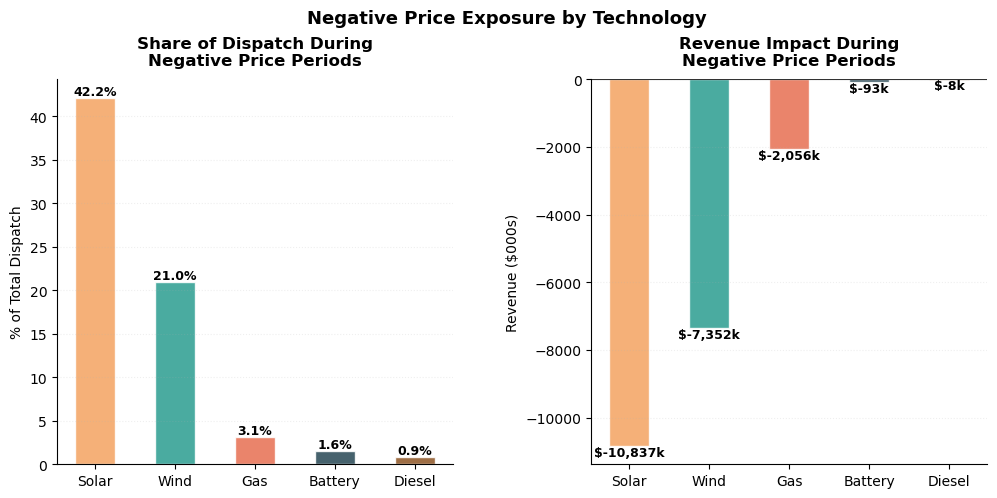

In [59]:
# VISUALISATION — 7

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         gridspec_kw={'wspace': 0.35})
fig.patch.set_facecolor('white')

tc = [colors_tech[t] for t in neg_df.index]

# Left — % of total dispatch occurring during negative prices
axes[0].bar(neg_df.index, neg_df['% of Total Dispatch'],
            color=tc, width=0.5, alpha=0.85, edgecolor='white')
axes[0].set_ylabel('% of Total Dispatch', fontsize=10)
axes[0].set_title('Share of Dispatch During\nNegative Price Periods',
                  fontweight='bold', fontsize=12, pad=10)
axes[0].grid(axis='y', alpha=0.2, linestyle=':')
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(neg_df['% of Total Dispatch']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# Right — revenue loss during negative price periods
rev_vals = neg_df['Revenue in Neg ($000s)']
axes[1].bar(neg_df.index, rev_vals,
            color=tc, width=0.5, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='#333333', linewidth=0.8)
axes[1].set_ylabel('Revenue ($000s)', fontsize=10)
axes[1].set_title('Revenue Impact During\nNegative Price Periods',
                  fontweight='bold', fontsize=12, pad=10)
axes[1].grid(axis='y', alpha=0.2, linestyle=':')
axes[1].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(rev_vals):
    axes[1].text(i, v - 300, f'${v:,.0f}k',
                 ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Negative Price Exposure by Technology',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(pad=2.5)
plt.savefig('q7_negative_prices.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# MASTER SUMMARY TABLE

print("=" * 70)
print("MASTER SUMMARY — ALL KEY METRICS BY TECHNOLOGY")
print("=" * 70)

summary = pd.DataFrame({
    'Capture Price ($/MWh)':    tech_dwp_series,
    'vs Time-Wtd ($/MWh)':     (tech_dwp_series - twp).round(2),
    'vs Vol-Wtd ($/MWh)':      (tech_dwp_series - vwp).round(2),
    'Total Rev FY23 ($M)':     annual_rev.iloc[0].round(2),
    'Total Rev FY24 ($M)':     annual_rev.iloc[1].round(2),
    'Monthly CoV (%)':         monthly_stats['CoV (%)'].round(2),
    'Capacity Factor (%)':     pd.Series(tech_cf).round(2),
    '% Dispatch Neg Price':    neg_df['% of Total Dispatch'],
})

print(summary.round(2).to_string())

MASTER SUMMARY — ALL KEY METRICS BY TECHNOLOGY
         Capture Price ($/MWh)  vs Time-Wtd ($/MWh)  vs Vol-Wtd ($/MWh)  Total Rev FY23 ($M)  Total Rev FY24 ($M)  Monthly CoV (%)  Capacity Factor (%)  % Dispatch Neg Price
Battery                 397.95               297.08              269.16                13.01                10.65            90.60                 2.05                  1.55
Diesel                  900.33               799.46              771.54                12.84                 7.52           154.77                 0.86                  0.89
Gas                     281.71               180.83              152.91               178.92               107.92           100.45                 8.89                  3.10
Solar                    42.48               -58.39              -86.31                13.98                 8.08           107.51                21.12                 42.16
Wind                     77.53               -23.34              -51.26            